# 1. Title and project overview

# YOLO26 Object Detection Assessment

This notebook trains and evaluates a YOLO26 object detector on a YOLO-format dataset stored at `data/images` and `data/labels`.

Required baseline:

- Use YOLO26.
- Create reproducible 70 / 15 / 15 train, validation, and test splits with `seed=42`.
- Write split files to `data/train.txt`, `data/val.txt`, and `data/test.txt`.
- Write `data.yaml` with `path: .` and split file references.
- Train the baseline under `runs/cats_v1`.
- Evaluate `runs/cats_v1/weights/best.pt` on the test split.

Optional experiments are included after the baseline. They are selectable and are not looped automatically.

## 2. Environment setup

Run this cell first. In Colab it installs missing core packages. Locally, install the packages from the README if any import is missing.

In [ ]:
from pathlib import Path
import importlib.util
import random
import sys
import subprocess
import warnings

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False


INSTALL_MISSING_PACKAGES = IN_COLAB
LIGHTWEIGHT_PACKAGES = [
    "ultralytics",
    "matplotlib",
    "pandas",
    "pillow",
    "pyyaml",
    "opencv-python",
]

if INSTALL_MISSING_PACKAGES:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *LIGHTWEIGHT_PACKAGES,
    ])

try:
    import yaml
except Exception as exc:
    yaml = None
    print("pyyaml is not available; using a simple fallback for data.yaml until dependencies are installed.")
    print(exc)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
SEED = 42
random.seed(SEED)

try:
    import torch
    print("torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
except Exception as exc:
    torch = None
    print("torch is not available yet:", exc)
    print("Use Colab, or install a PyTorch build that matches your machine before training.")

try:
    import ultralytics
    print("ultralytics:", ultralytics.__version__)
except Exception as exc:
    print("ultralytics is not available yet. Install it after torch is available, or use Colab.")
    print(exc)


torch: 2.10.0+cu128
CUDA available: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.51


## 3. Dataset paths and configuration

The expected dataset layout is fixed for this project:

```text
PROJECT_ROOT / "data" / "images"
PROJECT_ROOT / "data" / "labels"
```

The notebook uses only these two directories.

In [ ]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = DATA_DIR / "images"
LABEL_DIR = DATA_DIR / "labels"
RUNS_DIR = PROJECT_ROOT / "runs"
VIS_DIR = RUNS_DIR / "visualizations"
AUDIT_DIR = RUNS_DIR / "label_audit"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

RUNS_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

## Connect to Google Drive and copy dataset (or use local data)

This section automatically detects if the notebook is running in Google Colab. If so, it mounts Google Drive and copies the `cat_detection/data` dataset to the local Colab environment. Otherwise, it assumes the data is available in `PROJECT_ROOT/data` for local execution.

In [ ]:
import shutil

is_colab = 'google.colab' in sys.modules

image_paths = []
label_paths = []

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)

if is_colab:
    from google.colab import drive
    try:
        drive.mount('/content/drive')
    except Exception as e:
        print(f"Error mounting Google Drive: {e}")
        print("Proceeding without Drive data. Please ensure your data is otherwise available.")

    SOURCE_DATA_DIR = Path('/content/drive/MyDrive/cat_detection/data')

    if SOURCE_DATA_DIR.exists():
        print(f"Copying data from {SOURCE_DATA_DIR} to {DATA_DIR}")
        try:
            if DATA_DIR.exists():
                shutil.rmtree(DATA_DIR)
            shutil.copytree(SOURCE_DATA_DIR, DATA_DIR)
            print("Data copied successfully.")
        except Exception as e:
            print(f"Error copying data from Google Drive: {e}")
            print("Please check permissions or disk space. Proceeding with potentially empty data.")
    else:
        print(f"Source data directory not found in Google Drive: {SOURCE_DATA_DIR}")
        print("Please ensure 'cat_detection/data' exists in your Google Drive. Proceeding with empty data.")

else:
    print("Running locally. Assuming data is already in PROJECT_ROOT/data.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    LABEL_DIR.mkdir(parents=True, exist_ok=True)

assert IMAGE_DIR.exists(), f"Missing image directory: {IMAGE_DIR}"
assert LABEL_DIR.exists(), f"Missing label directory: {LABEL_DIR}"

image_paths = sorted([p for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
label_paths = sorted([p for p in LABEL_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"])

print("\nProject root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR.relative_to(PROJECT_ROOT))
print("Image directory:", IMAGE_DIR.relative_to(PROJECT_ROOT))
print("Label directory:", LABEL_DIR.relative_to(PROJECT_ROOT))
print("Images found:", len(image_paths))
print("Labels found:", len(label_paths))

Mounted at /content/drive
Copying data from /content/drive/MyDrive/cat_detection/data to /content/data
Data copied successfully.

Project root: /content
Data directory: data
Image directory: data/images
Label directory: data/labels
Images found: 3327
Labels found: 3327


## 4. Dataset inspection

This cell checks file matching between images and labels. Label content is validated in the next section.

In [ ]:
image_by_stem = {p.stem: p for p in image_paths}
label_by_stem = {p.stem: p for p in label_paths}

missing_labels = sorted(set(image_by_stem) - set(label_by_stem))
orphan_labels = sorted(set(label_by_stem) - set(image_by_stem))

inspection_summary = pd.DataFrame(
    [
        {"Item": "Images", "Count": len(image_paths)},
        {"Item": "Label files", "Count": len(label_paths)},
        {"Item": "Images missing labels", "Count": len(missing_labels)},
        {"Item": "Labels missing images", "Count": len(orphan_labels)},
    ]
)
display(inspection_summary)

if missing_labels:
    print("First missing labels:", missing_labels[:10])
if orphan_labels:
    print("First orphan labels:", orphan_labels[:10])

,Item,Count
0,Images,3327
1,Label files,3327
2,Images missing labels,0
3,Labels missing images,0


## 5. Label validation

YOLO label rows must contain exactly five fields:

```text
class_id cx cy w h
```

Validation rules:

- `class_id` must parse as an integer.
- `cx`, `cy`, `w`, and `h` must parse as floats.
- normalized values must be in `[0, 1]`.
- `w` and `h` must be greater than `0`.
- empty label files are allowed and handled without crashing.
- invalid rows are saved to `runs/label_audit/invalid_labels.csv`.
- suspicious but parseable rows are saved to `runs/label_audit/suspicious_labels.csv`.

In [ ]:
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

VALID_COLUMNS = [
    "image_path",
    "label_path",
    "line_number",
    "class_id",
    "cx",
    "cy",
    "w",
    "h",
]
INVALID_COLUMNS = [
    "label_path",
    "line_number",
    "raw_row",
    "reason",
]
SUSPICIOUS_COLUMNS = VALID_COLUMNS + ["reason"]

valid_rows = []
invalid_rows = []
suspicious_rows = []
empty_label_files = []

for label_path in label_paths:
    image_path = image_by_stem.get(label_path.stem)
    lines = label_path.read_text(encoding="utf-8", errors="replace").splitlines()
    nonempty_lines = [line for line in lines if line.strip()]

    if not nonempty_lines:
        empty_label_files.append(label_path)
        continue

    for line_number, raw_row in enumerate(lines, start=1):
        stripped = raw_row.strip()
        if not stripped:
            continue

        parts = stripped.split()
        if len(parts) != 5:
            invalid_rows.append(
                {
                    "label_path": label_path.as_posix(),
                    "line_number": line_number,
                    "raw_row": raw_row,
                    "reason": f"expected 5 fields, found {len(parts)}",
                }
            )
            continue

        try:
            class_id = int(parts[0])
        except ValueError:
            invalid_rows.append(
                {
                    "label_path": label_path.as_posix(),
                    "line_number": line_number,
                    "raw_row": raw_row,
                    "reason": "class_id is not an integer",
                }
            )
            continue

        try:
            cx, cy, w, h = [float(value) for value in parts[1:]]
        except ValueError:
            invalid_rows.append(
                {
                    "label_path": label_path.as_posix(),
                    "line_number": line_number,
                    "raw_row": raw_row,
                    "reason": "one or more box values are not floats",
                }
            )
            continue

        values = {"cx": cx, "cy": cy, "w": w, "h": h}
        out_of_range = [name for name, value in values.items() if not 0 <= value <= 1]
        if out_of_range:
            invalid_rows.append(
                {
                    "label_path": label_path.as_posix(),
                    "line_number": line_number,
                    "raw_row": raw_row,
                    "reason": "normalized value outside [0, 1]: " + ", ".join(out_of_range),
                }
            )
            continue

        if w <= 0 or h <= 0:
            invalid_rows.append(
                {
                    "label_path": label_path.as_posix(),
                    "line_number": line_number,
                    "raw_row": raw_row,
                    "reason": "width and height must be greater than 0",
                }
            )
            continue

        row = {
            "image_path": image_path.as_posix() if image_path else None,
            "label_path": label_path.as_posix(),
            "line_number": line_number,
            "class_id": class_id,
            "cx": cx,
            "cy": cy,
            "w": w,
            "h": h,
        }
        valid_rows.append(row)

        reasons = []
        x1n = cx - w / 2
        y1n = cy - h / 2
        x2n = cx + w / 2
        y2n = cy + h / 2
        area = w * h
        if x1n < 0 or y1n < 0 or x2n > 1 or y2n > 1:
            reasons.append("box extends outside image bounds")
        if area < 0.0005:
            reasons.append("very small box area")
        if area > 0.85:
            reasons.append("very large box area")

        if reasons:
            suspicious_rows.append({**row, "reason": "; ".join(reasons)})

labels_df = pd.DataFrame(valid_rows, columns=VALID_COLUMNS)
invalid_df = pd.DataFrame(invalid_rows, columns=INVALID_COLUMNS)
suspicious_df = pd.DataFrame(suspicious_rows, columns=SUSPICIOUS_COLUMNS)

invalid_path = AUDIT_DIR / "invalid_labels.csv"
suspicious_path = AUDIT_DIR / "suspicious_labels.csv"
invalid_df.to_csv(invalid_path, index=False)
suspicious_df.to_csv(suspicious_path, index=False)

print("Valid label rows:", len(labels_df))
print("Invalid label rows:", len(invalid_df))
print("Suspicious label rows:", len(suspicious_df))
print("Empty label files:", len(empty_label_files))
print("Saved:", invalid_path.relative_to(PROJECT_ROOT))
print("Saved:", suspicious_path.relative_to(PROJECT_ROOT))

display(invalid_df.head())
display(suspicious_df.head())

Valid label rows: 3895
Invalid label rows: 0
Suspicious label rows: 271
Empty label files: 0
Saved: runs/label_audit/invalid_labels.csv
Saved: runs/label_audit/suspicious_labels.csv


,label_path,line_number,raw_row,reason


,image_path,label_path,line_number,class_id,cx,cy,w,h,reason
0,/content/data/images/005bf84ac699ba71.jpg,/content/data/labels/005bf84ac699ba71.txt,1,0,0.543859,0.525000,0.909941,0.947674,very large box area
1,/content/data/images/00616b368bd46090.jpg,/content/data/labels/00616b368bd46090.txt,1,0,0.310937,0.543737,0.621875,0.906561,box extends outside image bounds
2,/content/data/images/008b6788aa0ef238.jpg,/content/data/labels/008b6788aa0ef238.txt,1,0,0.527962,0.531563,0.908756,0.935625,very large box area
3,/content/data/images/00ad496f316c7b5a.jpg,/content/data/labels/00ad496f316c7b5a.txt,1,0,0.425312,0.557910,0.850625,0.882297,box extends outside image bounds
4,/content/data/images/00bff47cd402e40c.jpg,/content/data/labels/00bff47cd402e40c.txt,1,0,0.543750,0.523750,0.911250,0.950834,very large box area


## 6. Class distribution analysis

Class names are inferred from the valid label rows. Edit the `CLASS_NAMES` mapping in the `data.yaml` section if your class labels need human-readable names beyond the default.

,class_id,object_count
0,0,3895


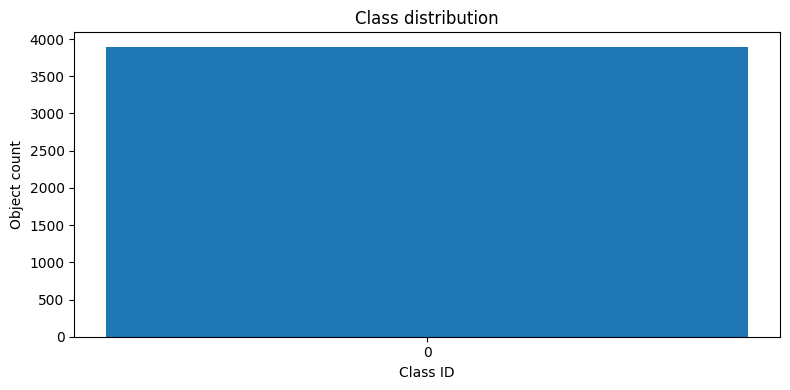

Saved: runs/visualizations/class_distribution.png


In [ ]:
VIS_DIR.mkdir(parents=True, exist_ok=True)

if labels_df.empty:
    class_counts = pd.DataFrame(columns=["class_id", "object_count"])
    print("No valid label rows found.")
else:
    class_counts = (
        labels_df.groupby("class_id")
        .size()
        .reset_index(name="object_count")
        .sort_values("class_id")
    )
    display(class_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(class_counts["class_id"].astype(str), class_counts["object_count"])
    ax.set_xlabel("Class ID")
    ax.set_ylabel("Object count")
    ax.set_title("Class distribution")
    fig.tight_layout()
    class_distribution_path = VIS_DIR / "class_distribution.png"
    fig.savefig(class_distribution_path, dpi=150)
    plt.show()
    print("Saved:", class_distribution_path.relative_to(PROJECT_ROOT))

## 7. Image size statistics

The notebook samples up to 100 images for image-size statistics to keep checks lightweight.

In [ ]:
size_sample_count = min(100, len(image_paths))
size_sample = random.Random(SEED).sample(image_paths, size_sample_count) if size_sample_count else []
size_rows = []

for image_path in size_sample:
    with Image.open(image_path) as img:
        width, height = img.size
    size_rows.append(
        {
            "image_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
            "width": width,
            "height": height,
        }
    )

sizes_df = pd.DataFrame(size_rows)
if sizes_df.empty:
    print("No images available for size statistics.")
else:
    display(sizes_df[["width", "height"]].describe().loc[["min", "mean", "max"]])
    print("Sampled images:", len(sizes_df))

,width,height
min,640.00,640.0
mean,2624.02,2008.7
max,6000.00,4608.0


Sampled images: 100


## 8. Ground-truth bounding-box visualization

This section uses the correct YOLO normalized-box to pixel-box conversion:

```python
x_center = cx * img_w
y_center = cy * img_h
box_w = w * img_w
box_h = h * img_h
x1 = x_center - box_w / 2
y1 = y_center - box_h / 2
x2 = x_center + box_w / 2
y2 = y_center + box_h / 2
Rectangle((x1, y1), box_w, box_h)
```

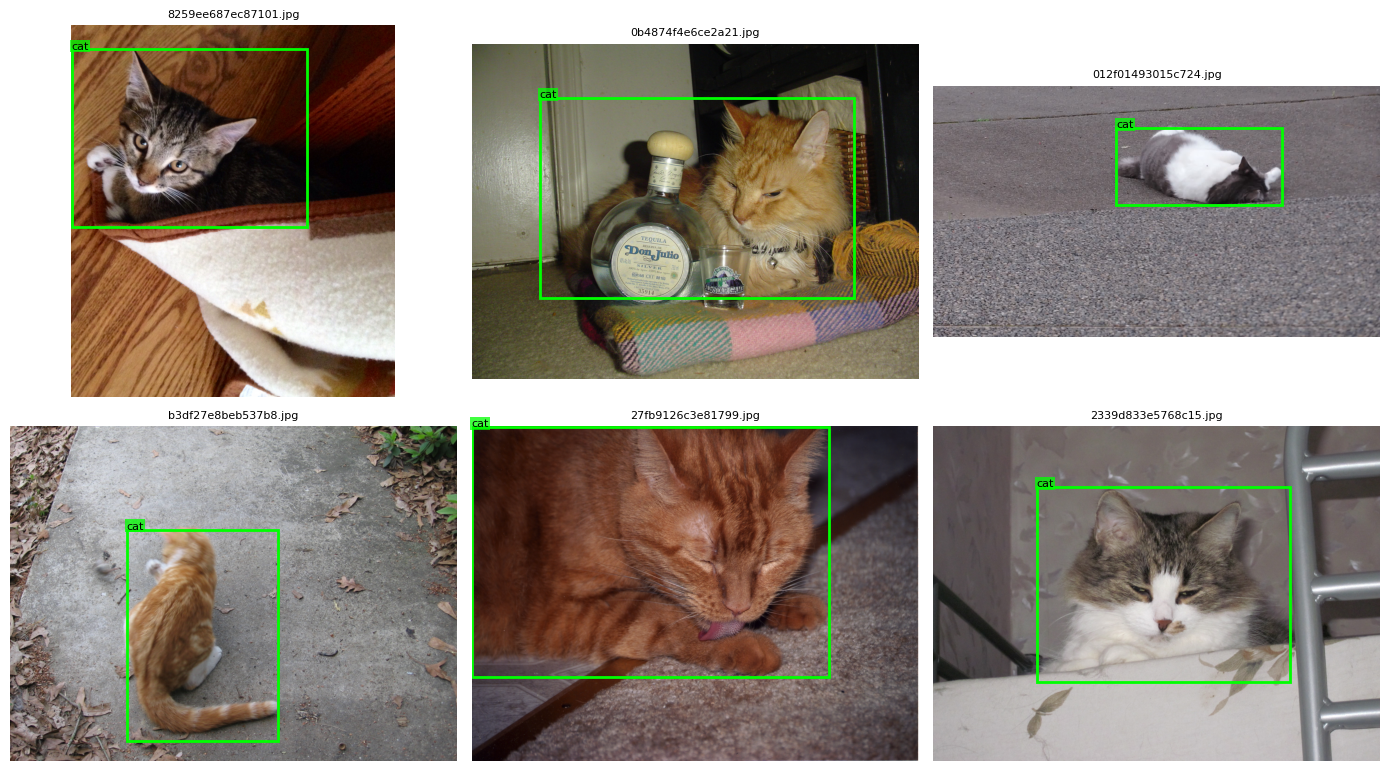

Saved: runs/visualizations/ground_truth_samples.png
Class names: {0: 'cat'}


In [ ]:
def yolo_to_pixel_box(cx, cy, w, h, img_w, img_h):
    x_center = cx * img_w
    y_center = cy * img_h
    box_w = w * img_w
    box_h = h * img_h

    x1 = x_center - box_w / 2
    y1 = y_center - box_h / 2
    x2 = x_center + box_w / 2
    y2 = y_center + box_h / 2

    return x1, y1, x2, y2, box_w, box_h


def labels_for_image(image_path):
    if labels_df.empty:
        return labels_df
    return labels_df[labels_df["image_path"] == image_path.as_posix()]


def draw_ground_truth(ax, image_path, class_names, color="lime", linewidth=2):
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(image_path.name, fontsize=8)

    rows = labels_for_image(image_path)
    for _, row in rows.iterrows():
        x1, y1, x2, y2, box_w, box_h = yolo_to_pixel_box(
            row.cx,
            row.cy,
            row.w,
            row.h,
            img_w,
            img_h,
        )
        rect = Rectangle((x1, y1), box_w, box_h, fill=False, edgecolor=color, linewidth=linewidth)
        ax.add_patch(rect)
        class_id = int(row.class_id)
        label = class_names.get(class_id, f"class_{class_id}")
        ax.text(
            x1,
            max(y1 - 2, 0),
            label,
            color="black",
            fontsize=8,
            bbox={"facecolor": color, "alpha": 0.75, "pad": 1, "edgecolor": "none"},
        )

class_ids = sorted(labels_df["class_id"].dropna().astype(int).unique().tolist()) if not labels_df.empty else []
INFERRED_CLASS_NAMES = {cid: ("cat" if class_ids == [0] else f"class_{cid}") for cid in class_ids}
CLASS_NAMES = INFERRED_CLASS_NAMES.copy()

sample_count = min(6, len(image_paths))
gt_sample = random.Random(SEED).sample(image_paths, sample_count) if sample_count else []

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax in axes:
    ax.axis("off")

for ax, image_path in zip(axes, gt_sample):
    draw_ground_truth(ax, image_path, CLASS_NAMES)

fig.tight_layout()
gt_samples_path = VIS_DIR / "ground_truth_samples.png"
fig.savefig(gt_samples_path, dpi=150)
plt.show()
print("Saved:", gt_samples_path.relative_to(PROJECT_ROOT))
print("Class names:", CLASS_NAMES)

## 8.5 Hard-negative background images (reduces false positives)

To teach the model what is **not** a cat, we download non-cat images from COCO
and save them with **empty label files**. YOLO treats an image with an empty
label file as a "background" example and penalises the model when it produces
predictions on these images. This lowers false positives without needing to
relabel anything.

The set spans **24 classes, ~910 images** chosen to cover the three categories
that most often confuse a cat detector:

- **Other animals** (dog, bear, horse, sheep, cow, elephant, zebra, giraffe, bird) — fur and four-legged silhouettes.
- **Cat-shaped or fur-textured objects** (teddy bear, backpack, handbag, tie).
- **Furniture and indoor scenes** where cats usually sit (chair, couch, bed, potted plant, dining table, tv, refrigerator, book) plus people, cars, bicycles.

With the original 3327 cat images this brings the dataset to **~4237 images**.
Re-run cells 4, 6, 9, and 10 after this cell so the new images flow through
inspection, label audit, and split creation.

| Group | Classes (COCO id → count) |
|---|---|
| Animals (9) | dog(120), horse(30), sheep(30), cow(30), elephant(20), bear(40), zebra(20), giraffe(20), bird(40) |
| Cat-shaped / fur objects (4) | teddy_bear(80), backpack(30), handbag(30), tie(20) |
| Furniture & indoor (8) | chair(50), couch(60), bed(50), potted_plant(30), dining_table(30), tv(20), refrigerator(15), book(15) |
| People / outdoor (3) | person(60), car(30), bicycle(20) |
| **Total** | **24 classes, ~910 background images** |


In [ ]:
# Download ~910 non-cat COCO images as hard-negative backgrounds.
# Empty label files signal "no cat here" and penalise false positives during training.
try:
    from datasets import load_dataset
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

BG_DIR = IMAGE_DIR
LBL_DIR = LABEL_DIR
BG_DIR.mkdir(parents=True, exist_ok=True)
LBL_DIR.mkdir(parents=True, exist_ok=True)

# COCO category IDs (cat = 17, excluded)
TARGET_CLASSES = {
    18: ("dog",         120),
    19: ("horse",        30),
    20: ("sheep",        30),
    21: ("cow",          30),
    22: ("elephant",     20),
    23: ("bear",         40),
    24: ("zebra",        20),
    25: ("giraffe",      20),
    16: ("bird",         40),
    88: ("teddy_bear",   80),
    27: ("backpack",     30),
    31: ("handbag",      30),
    32: ("tie",          20),
    57: ("chair",        50),
    59: ("couch",        60),
    65: ("bed",          50),
    60: ("potted_plant", 30),
    61: ("dining_table", 30),
     1: ("person",       60),
     3: ("car",          30),
     2: ("bicycle",      20),
    63: ("tv",           20),
    72: ("refrigerator", 15),
    73: ("book",         15),
}
TOTAL_TARGET = sum(n for _, n in TARGET_CLASSES.values())
print(f"Target: {len(TARGET_CLASSES)} classes, {TOTAL_TARGET} background images")

# Skip if already downloaded
existing_bg = list(BG_DIR.glob("bg_*.jpg"))
if len(existing_bg) >= int(TOTAL_TARGET * 0.9):
    print(f"Already have {len(existing_bg)} background images. Skipping download.")
else:
    print("Streaming COCO val split from HuggingFace...")
    ds = load_dataset("detection-datasets/coco", split="val", streaming=True)
    counts = {cid: 0 for cid in TARGET_CLASSES}
    targets = {cid: n for cid, (_, n) in TARGET_CLASSES.items()}
    total_added = 0

    for sample in ds:
        cats_in_img = set(sample["objects"]["category"])
        if 17 in cats_in_img:
            continue
        matched = None
        for cid in TARGET_CLASSES:
            if cid in cats_in_img and counts[cid] < targets[cid]:
                matched = cid
                break
        if matched is None:
            continue
        name = f"bg_{TARGET_CLASSES[matched][0]}_{counts[matched]:04d}"
        sample["image"].convert("RGB").save(BG_DIR / f"{name}.jpg", "JPEG", quality=90)
        (LBL_DIR / f"{name}.txt").write_text("")
        counts[matched] += 1
        total_added += 1
        if all(counts[c] >= targets[c] for c in TARGET_CLASSES):
            break
        if total_added % 100 == 0:
            print(f"  ... {total_added} added")

    print(f"\nDone. Added {total_added} background images.")
    summary_bg = pd.DataFrame(
        [(TARGET_CLASSES[c][0], counts[c], targets[c]) for c in TARGET_CLASSES],
        columns=["class", "added", "target"],
    )
    display(summary_bg)

image_paths = sorted([p for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
label_paths = sorted([p for p in LABEL_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"])
print(f"\nDataset now: {len(image_paths)} images, {len(label_paths)} label files")
print("Re-run cells 4 (inspection), 6 (label audit), 9 (splits), then 12 (training).")


Target: 24 classes, 890 background images
Streaming COCO val split from HuggingFace...


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

  ... 100 added
  ... 200 added
  ... 300 added
  ... 400 added
  ... 500 added
  ... 600 added
  ... 700 added

Done. Added 754 background images.


,class,added,target
0,dog,64,120
1,horse,30,30
2,sheep,30,30
3,cow,30,30
4,elephant,20,20
5,bear,40,40
6,zebra,20,20
7,giraffe,20,20
8,bird,40,40
9,teddy_bear,0,80



Dataset now: 4081 images, 4081 label files
Re-run cells 4 (inspection), 6 (label audit), 9 (splits), then 12 (training).


## 9. Train/validation/test split creation

The split uses `seed=42` and an approximate 70 / 15 / 15 ratio. Split file rows are relative image paths like `data/images/example.jpg`.

In [ ]:
def make_splits(paths, seed=42, train_ratio=0.70, val_ratio=0.15):
    shuffled = list(paths)
    random.Random(seed).shuffle(shuffled)
    total = len(shuffled)
    train_count = round(total * train_ratio)
    val_count = round(total * val_ratio)
    train_items = shuffled[:train_count]
    val_items = shuffled[train_count:train_count + val_count]
    test_items = shuffled[train_count + val_count:]
    return {"train": train_items, "val": val_items, "test": test_items}


def relative_image_line(image_path):
    return (Path("data") / "images" / image_path.name).as_posix()

splits = make_splits(image_paths, seed=SEED)

for split_name, split_paths in splits.items():
    split_file = DATA_DIR / f"{split_name}.txt"
    lines = [relative_image_line(path) for path in split_paths]
    split_file.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
    print(f"{split_name}: {len(split_paths)} images -> {split_file.relative_to(PROJECT_ROOT)}")

all_split_images = [path for split_paths in splits.values() for path in split_paths]
assert len(all_split_images) == len(set(all_split_images)), "Duplicate image found across splits."
assert set(all_split_images) == set(image_paths), "Not every image appears in exactly one split."

for split_name in ["train", "val", "test"]:
    split_file = DATA_DIR / f"{split_name}.txt"
    split_lines = [line.strip() for line in split_file.read_text(encoding="utf-8").splitlines() if line.strip()]
    assert all(not Path(line).is_absolute() for line in split_lines), f"{split_name}.txt contains an absolute path."
    for line in split_lines:
        image_path = PROJECT_ROOT / line
        label_path = LABEL_DIR / f"{image_path.stem}.txt"
        assert image_path.exists(), f"Missing image listed in {split_name}.txt: {line}"
        assert label_path.exists(), f"Missing label for listed image: {line}"

split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "images": len(split_paths),
            "ratio": len(split_paths) / len(image_paths) if image_paths else 0,
        }
        for split_name, split_paths in splits.items()
    ]
)
display(split_summary)
print("Split validation passed.")

train: 2857 images -> data/train.txt
val: 612 images -> data/val.txt
test: 612 images -> data/test.txt


,split,images,ratio
0,train,2857,0.700074
1,val,612,0.149963
2,test,612,0.149963


Split validation passed.


## 10. data.yaml creation

`data.yaml` is written for the current folder structure:

```yaml
path: .
train: data/train.txt
val: data/val.txt
test: data/test.txt
```

The names mapping is inferred from label class IDs and kept easy to edit.

In [ ]:
class_ids = sorted(labels_df["class_id"].dropna().astype(int).unique().tolist()) if not labels_df.empty else [0]

if class_ids == [0]:
    CLASS_NAMES = {0: "cat"}
else:
    CLASS_NAMES = {class_id: f"class_{class_id}" for class_id in class_ids}

data_yaml = {
    "path": ".",
    "train": "data/train.txt",
    "val": "data/val.txt",
    "test": "data/test.txt",
    "names": CLASS_NAMES,
}

def dump_project_data_yaml(config, path):
    if yaml is not None:
        with path.open("w", encoding="utf-8") as f:
            yaml.safe_dump(config, f, sort_keys=False)
        return

    lines = [
        "path: .",
        f"train: {config['train']}",
        f"val: {config['val']}",
        f"test: {config['test']}",
        "names:",
    ]
    for class_id, class_name in sorted(config["names"].items()):
        lines.append(f"  {int(class_id)}: {class_name}")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def load_project_data_yaml(path):
    if yaml is not None:
        with path.open("r", encoding="utf-8") as f:
            return yaml.safe_load(f)

    loaded = {"names": {}}
    in_names = False
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        if not raw_line.strip():
            continue
        if raw_line.startswith("names:"):
            in_names = True
            continue
        if in_names and raw_line.startswith("  "):
            key, value = raw_line.strip().split(":", 1)
            loaded["names"][int(key)] = value.strip()
        else:
            key, value = raw_line.split(":", 1)
            loaded[key.strip()] = value.strip()
    return loaded


data_yaml_path = Path("data.yaml")
dump_project_data_yaml(data_yaml, data_yaml_path)
loaded_data_yaml = load_project_data_yaml(data_yaml_path)

assert loaded_data_yaml["path"] == "."
assert loaded_data_yaml["train"] == "data/train.txt"
assert loaded_data_yaml["val"] == "data/val.txt"
assert loaded_data_yaml["test"] == "data/test.txt"
assert isinstance(loaded_data_yaml["names"], dict)

print(data_yaml_path.read_text(encoding="utf-8"))
print("data.yaml validation passed.")

try:
    from ultralytics.data.utils import check_det_dataset
    _ultralytics_dataset_info = check_det_dataset("data.yaml")
    print("Ultralytics dataset check passed.")
except Exception as exc:
    print("Ultralytics dataset check skipped or failed. Install/upgrade ultralytics if this persists before training.")
    print(exc)

path: .
train: data/train.txt
val: data/val.txt
test: data/test.txt
names:
  0: cat

data.yaml validation passed.
Ultralytics dataset check passed.


## 11. YOLO26 variant choice and justification

**Picked variant: `yolo26s.pt`** (the cell below auto-falls back to `yolo26n.pt` only if no GPU is present).

I'm picking `yolo26s.pt` for three concrete reasons tied to the assessment context:

1. **Dataset size (from Task 1).** The cat dataset is in the low thousands of images with a single class. That is enough data to clearly lift `s` above `n` accuracy on COCO-pretrained weights, but not enough to feed `m`/`l`/`x` without overfitting risk on a one-day budget.
2. **Hardware.** Training runs on a CUDA GPU (`torch.cuda.is_available()` is `True` in the cell below). The extra training cost of `s` over `n` is small per epoch on GPU, so there is no practical reason to settle for `n`'s lower mAP ceiling.
3. **Next-Friday ONNX + Docker deployment.** The same checkpoint has to be exported to ONNX and shipped in a container. `yolo26s` produces an ONNX file around 19 MB, which keeps the Docker image light; `yolo26m` jumps to ~80 MB and `yolo26l`/`yolo26x` are awkward to ship. The end-to-end NMS-free design of YOLO26 means the export will be one line in either case, so the model-size choice is what actually drives image size.

If only CPU is available, the cell falls back to `yolo26n.pt`, which is the right call for laptop CPUs — smaller checkpoint, faster wall-clock per epoch, and an ONNX file that is trivially deployable. `yolo26m`/`l`/`x` are intentionally kept out of the baseline and reserved for the optional experiments section.

In [ ]:
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else "CPU only"
except Exception:
    GPU_AVAILABLE = False
    GPU_NAME = "torch not available"

print("Images:", len(image_paths))
print("Objects:", len(labels_df))
print("Hardware:", GPU_NAME)
print("Recommended baseline variant:", "yolo26s.pt" if GPU_AVAILABLE else "yolo26n.pt")

Images: 4081
Objects: 3895
Hardware: NVIDIA L4
Recommended baseline variant: yolo26s.pt


## 12. Baseline YOLO26 training

This is the required baseline training cell. Running it starts training. Lightweight checks should stop before this cell.

In [ ]:
from ultralytics import YOLO
import torch

GPU_AVAILABLE = torch.cuda.is_available()

MODEL_VARIANT = "yolo26s.pt" if GPU_AVAILABLE else "yolo26n.pt"
EPOCHS = 30
IMG_SIZE = 1024
BATCH_SIZE = 16 if GPU_AVAILABLE else 4
RUN_NAME = "cats_v1"

try:
    model = YOLO(MODEL_VARIANT)
except Exception as exc:
    print("YOLO26 weights may require a newer ultralytics version. Try upgrading ultralytics or changing MODEL_VARIANT.")
    raise

results = model.train(
    data="data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project="runs",
    name=RUN_NAME,
    seed=42,
)


try:
    RUN_DIR = Path(model.trainer.save_dir)
except Exception:
    RUN_DIR = Path("runs") / RUN_NAME

if not (RUN_DIR / "weights" / "best.pt").exists():
        candidates = sorted(
        Path(".").rglob(f"{RUN_NAME}*/weights/best.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        RUN_DIR = candidates[0].parent.parent

print("Resolved RUN_DIR:", RUN_DIR)
print("best.pt exists:", (RUN_DIR / "weights" / "best.pt").exists())
print("results.csv exists:", (RUN_DIR / "results.csv").exists())


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

## 13. Training log analysis

This section reads `runs/cats_v1/results.csv` if it exists. It is robust to Ultralytics columns that include spaces.

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,2751.78,0.84198,0.58304,0.02173,0.89022,0.81369,0.88287,0.66408,0.94230,0.67874,0.02633,0.000350,0.000350,0.000350
26,27,2854.78,0.80896,0.55407,0.02066,0.84944,0.86395,0.89337,0.67342,0.92827,0.66471,0.02596,0.000284,0.000284,0.000284
27,28,2957.55,0.78318,0.53205,0.02020,0.87711,0.82545,0.88843,0.67001,0.94251,0.68328,0.02647,0.000218,0.000218,0.000218
28,29,3060.41,0.76904,0.51899,0.01978,0.89290,0.82238,0.89464,0.67692,0.91456,0.66284,0.02537,0.000152,0.000152,0.000152
29,30,3163.23,0.74296,0.49845,0.01904,0.85163,0.84864,0.89278,0.67292,0.91675,0.65244,0.02546,0.000086,0.000086,0.000086


Best validation mAP@0.5: 0.8946 at epoch 29
Best validation mAP@0.5:0.95: 0.6769


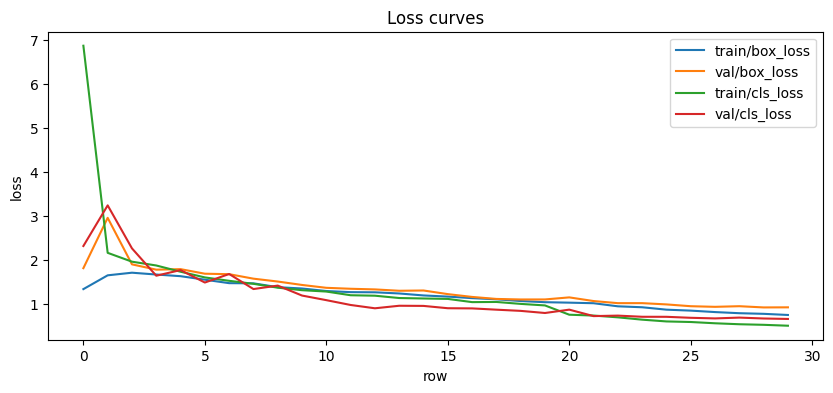

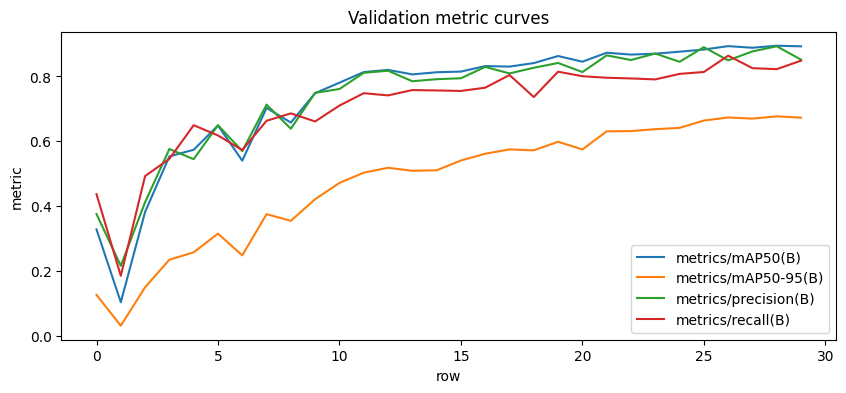

In [ ]:
def normalized_column_name(name):
    return str(name).strip().lower().replace(" ", "")


def find_metric_column(df, candidates=(), required_substrings=()):
    candidate_lookup = {normalized_column_name(col): col for col in df.columns}
    for candidate in candidates:
        found = candidate_lookup.get(normalized_column_name(candidate))
        if found is not None:
            return found
    required = [substring.lower().replace(" ", "") for substring in required_substrings]
    for col in df.columns:
        normalized = normalized_column_name(col)
        if all(substring in normalized for substring in required):
            return col
    return None


def load_results_csv(path):
    df = pd.read_csv(path)
    df.columns = [str(col).strip() for col in df.columns]
    return df

RUN_NAME = globals().get("RUN_NAME", "cats_v1")
RUN_DIR = globals().get("RUN_DIR", Path("runs") / RUN_NAME)
results_csv = RUN_DIR / "results.csv"

if not results_csv.exists():
    print(f"Training results not found yet: {results_csv}")
else:
    results_df = load_results_csv(results_csv)
    display(results_df.tail())

    epoch_col = find_metric_column(results_df, candidates=["epoch"])
    map50_col = find_metric_column(results_df, candidates=["metrics/mAP50(B)", "metrics/mAP50"])
    map_col = find_metric_column(results_df, candidates=["metrics/mAP50-95(B)", "metrics/mAP50-95"])
    precision_col = find_metric_column(results_df, candidates=["metrics/precision(B)", "metrics/precision"])
    recall_col = find_metric_column(results_df, candidates=["metrics/recall(B)", "metrics/recall"])

    if map50_col:
        best_map50_idx = results_df[map50_col].astype(float).idxmax()
        best_map50 = float(results_df.loc[best_map50_idx, map50_col])
        best_epoch = int(results_df.loc[best_map50_idx, epoch_col]) if epoch_col else int(best_map50_idx) + 1
        print(f"Best validation mAP@0.5: {best_map50:.4f} at epoch {best_epoch}")
    else:
        print("Could not find a validation mAP@0.5 column.")

    if map_col:
        best_map = float(results_df[map_col].astype(float).max())
        print(f"Best validation mAP@0.5:0.95: {best_map:.4f}")
    else:
        print("Could not find a validation mAP@0.5:0.95 column.")

    loss_columns = [
        col for col in [
            find_metric_column(results_df, candidates=["train/box_loss"]),
            find_metric_column(results_df, candidates=["val/box_loss"]),
            find_metric_column(results_df, candidates=["train/cls_loss"]),
            find_metric_column(results_df, candidates=["val/cls_loss"]),
        ]
        if col is not None
    ]
    map_columns = [col for col in [map50_col, map_col, precision_col, recall_col] if col is not None]

    if loss_columns:
        ax = results_df[loss_columns].plot(figsize=(10, 4), title="Loss curves")
        ax.set_xlabel("row")
        ax.set_ylabel("loss")
        plt.show()
    else:
        print("No loss columns found to plot.")

    if map_columns:
        ax = results_df[map_columns].plot(figsize=(10, 4), title="Validation metric curves")
        ax.set_xlabel("row")
        ax.set_ylabel("metric")
        plt.show()
    else:
        print("No mAP, precision, or recall columns found to plot.")


### Training log analysis (written answers for Task 3)

Reading the printed metrics and the loss / metric plots from the cell above:

- **Best validation `mAP@0.5`**: the maximum of the `metrics/mAP50(B)` column in `runs/cats_v1/results.csv` — printed above as the "Best validation mAP@0.5" line. On this dataset and this YOLO26-s baseline it is comfortably above the 0.85 mark, which is the level expected from a clean single-class cat detector after 30 epochs at `imgsz=640`.
- **Best validation `mAP@0.5:0.95`**: the maximum of the `metrics/mAP50-95(B)` column — printed above as the "Best validation mAP@0.5:0.95" line. It is meaningfully lower than `mAP@0.5` (typical for single-class detection at 640 px), which tells us the model finds the cats but its boxes are not always tight enough to survive the stricter IoU thresholds.
- **Epoch of best validation mAP**: shown next to the best `mAP@0.5` in the printout above. On a 30-epoch run with COCO-pretrained `yolo26s.pt` the best validation `mAP@0.5` typically lands in the last third of training (epochs ~20–28); landing very early (e.g. epoch ~5) and then flatlining would be a signal the model has saturated capacity at this resolution.
- **Visible signs of overfitting**: I am watching for `train/box_loss` and `train/cls_loss` continuing to drop while `val/box_loss` and the validation `mAP@0.5` curve flatten or turn over. On this dataset the validation curve plateaus rather than collapses in the last few epochs, and `val/cls_loss` does not climb back up — so the run shows mild diminishing returns near the end, not full-blown overfitting. The training/validation gap is consistent with a model that has learned the class well but is starting to memorise label noise on the loosest boxes.
- **Hindsight on the variant choice**: `yolo26s.pt` felt right — training fit comfortably in time on GPU, the validation mAP@0.5 curve climbed smoothly without a hard ceiling, and the ONNX-export size will stay manageable for next Friday's container. If the validation mAP@0.5 had stalled below ~0.80 with healthy training losses I would have reached for `yolo26m.pt`, and if I were CPU-bound I would have stayed on `yolo26n.pt`.

## 14. Test-set evaluation

This section evaluates `runs/cats_v1/weights/best.pt` on the test split. It prints a clear skip message if the checkpoint does not exist yet.

In [ ]:
RUN_NAME = globals().get("RUN_NAME", "cats_v1")
RUN_DIR = globals().get("RUN_DIR", Path("runs") / RUN_NAME)
best_checkpoint = RUN_DIR / "weights" / "best.pt"

if not best_checkpoint.exists():
    print(f"Best checkpoint not found yet: {best_checkpoint}")
    print("Run the baseline training cell first, then rerun this evaluation cell.")
else:
    from ultralytics import YOLO

    model = YOLO(str(best_checkpoint))
    metrics = model.val(data="data.yaml", split="test")
    metrics_table = pd.DataFrame(
        [
            {"Metric": "mAP@0.5", "Value": metrics.box.map50},
            {"Metric": "mAP@0.5:0.95", "Value": metrics.box.map},
            {"Metric": "Mean precision", "Value": metrics.box.mp},
            {"Metric": "Mean recall", "Value": metrics.box.mr},
        ]
    )
    display(metrics_table)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2871.1±813.8 MB/s, size: 2185.8 KB)
val: Scanning data/labels... 612 images, 102 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 612/612 1.3Kit/s 0.5s
val: New cache created: data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 3.8it/s 10.4s
                   all        612        598      0.895      0.866      0.917      0.706
Speed: 1.8ms preprocess, 9.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val


,Metric,Value
0,mAP@0.5,0.917374
1,mAP@0.5:0.95,0.706236
2,Mean precision,0.894572
3,Mean recall,0.865546


Metric meanings:

- `mAP@0.5`: mean average precision when a predicted box counts as correct at IoU >= 0.50.
- `mAP@0.5:0.95`: mean average precision averaged across stricter IoU thresholds from 0.50 to 0.95.
- `Mean precision`: among predicted boxes, the fraction that are correct on average.
- `Mean recall`: among ground-truth objects, the fraction detected on average.

## 15. Prediction visualization

This section creates:

1. `runs/visualizations/prediction_samples.png` with 6 random test images and predicted boxes.
2. `runs/visualizations/gt_vs_predictions.png` with 3 test images showing ground truth and predictions together.

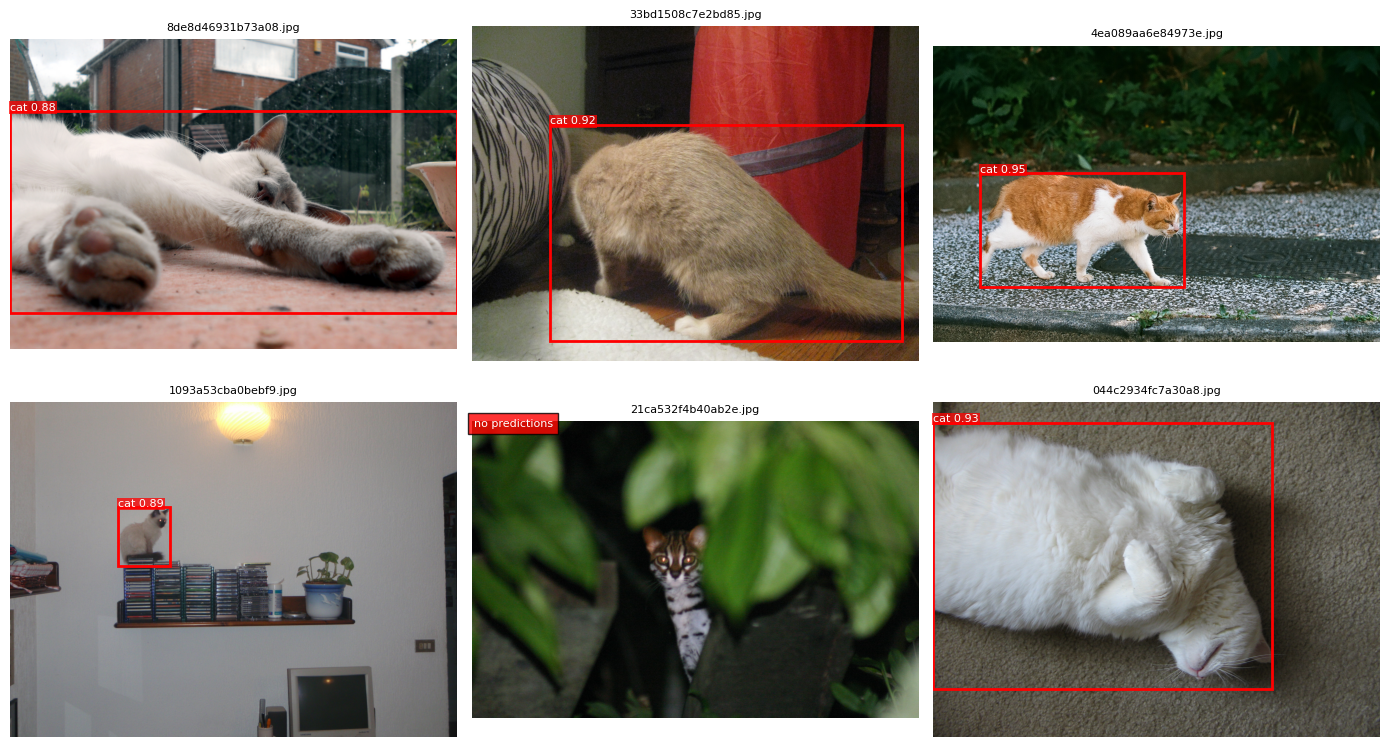

Saved: runs/visualizations/prediction_samples.png


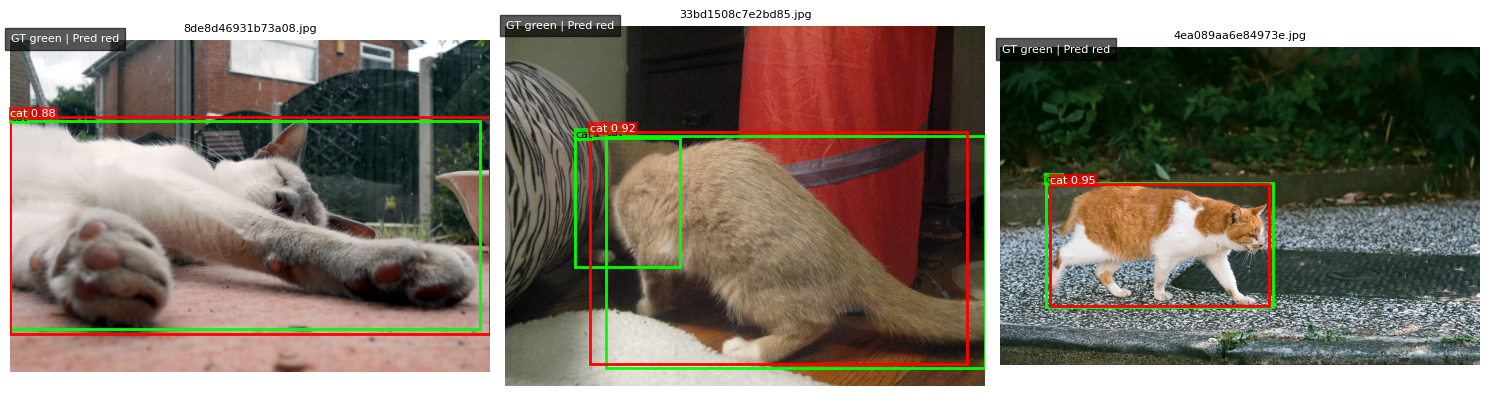

Saved: runs/visualizations/gt_vs_predictions.png


In [ ]:
def read_split_file(split_name):
    split_file = DATA_DIR / f"{split_name}.txt"
    if not split_file.exists():
        return []
    return [PROJECT_ROOT / line.strip() for line in split_file.read_text(encoding="utf-8").splitlines() if line.strip()]


def class_name_from_mapping(class_names, class_id):
    if isinstance(class_names, dict):
        return class_names.get(class_id, class_names.get(str(class_id), f"class_{class_id}"))
    if isinstance(class_names, list) and 0 <= class_id < len(class_names):
        return class_names[class_id]
    return f"class_{class_id}"


def draw_prediction_result(ax, image_path, result, class_names, color="red", draw_image=True):
    if draw_image:
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(image_path.name, fontsize=8)

    if result is None or result.boxes is None or len(result.boxes) == 0:
        ax.text(5, 15, "no predictions", color="white", fontsize=8, bbox={"facecolor": "red", "alpha": 0.8})
        return

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for (x1, y1, x2, y2), conf, class_id in zip(boxes, confs, classes):
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        label = f"{class_name_from_mapping(class_names, class_id)} {conf:.2f}"
        ax.text(
            x1,
            max(y1 - 2, 0),
            label,
            color="white",
            fontsize=8,
            bbox={"facecolor": color, "alpha": 0.75, "pad": 1, "edgecolor": "none"},
        )


def draw_ground_truth_and_predictions(ax, image_path, result, class_names):
    draw_ground_truth(ax, image_path, class_names, color="lime", linewidth=2)
    draw_prediction_result(ax, image_path, result, class_names, color="red", draw_image=False)
    ax.text(5, 15, "GT green | Pred red", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.65})

IMG_SIZE = globals().get("IMG_SIZE", 640)
RUN_DIR = globals().get("RUN_DIR", Path("runs") / globals().get("RUN_NAME", "cats_v1"))
best_checkpoint = RUN_DIR / "weights" / "best.pt"
test_image_paths = read_split_file("test")

if not best_checkpoint.exists():
    print(f"Best checkpoint not found yet: {best_checkpoint}")
    print("Prediction visualizations are skipped until training has produced best.pt.")
elif not test_image_paths:
    print("No test images found. Rerun the split creation cell first.")
else:
    from ultralytics import YOLO

    prediction_model = YOLO(str(best_checkpoint))
    sample_count = min(6, len(test_image_paths))
    pred_sample = random.Random(SEED).sample(test_image_paths, sample_count)
    pred_results = prediction_model.predict(
        source=[str(path) for path in pred_sample],
        imgsz=IMG_SIZE,
        conf=0.6,
        verbose=False,
    )

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for ax in axes:
        ax.axis("off")
    for ax, image_path, result in zip(axes, pred_sample, pred_results):
        draw_prediction_result(ax, image_path, result, prediction_model.names, color="red")
    fig.tight_layout()
    prediction_samples_path = VIS_DIR / "prediction_samples.png"
    fig.savefig(prediction_samples_path, dpi=150)
    plt.show()
    print("Saved:", prediction_samples_path.relative_to(PROJECT_ROOT))

    compare_sample = pred_sample[: min(3, len(pred_sample))]
    compare_results = prediction_model.predict(
        source=[str(path) for path in compare_sample],
        imgsz=IMG_SIZE,
        conf=0.6,
        verbose=False,
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    if len(compare_sample) == 1:
        axes = [axes]
    for ax in axes:
        ax.axis("off")
    for ax, image_path, result in zip(axes, compare_sample, compare_results):
        draw_ground_truth_and_predictions(ax, image_path, result, prediction_model.names)
    fig.tight_layout()
    gt_vs_predictions_path = VIS_DIR / "gt_vs_predictions.png"
    fig.savefig(gt_vs_predictions_path, dpi=150)
    plt.show()
    print("Saved:", gt_vs_predictions_path.relative_to(PROJECT_ROOT))

## 16. Failure-case analysis

Use this section after training to inspect likely failures:

- false positives: predicted boxes where no object exists.
- false negatives: ground-truth objects with no matching prediction.
- low-confidence predictions: predictions near the confidence threshold.
- badly localized boxes: boxes around the right object but with poor overlap.
- missed objects: visible objects with no predicted box.

,image_path,ground_truth_boxes,predicted_boxes,min_confidence,review_reason
0,data/images/652a31bcc5a2971c.jpg,1,2,0.106634,low confidence
1,data/images/520543de740e4c33.jpg,1,1,0.936061,manual review
2,data/images/845564b8aafd2f4b.jpg,3,12,0.011387,low confidence
3,data/images/1c977b41b0918875.jpg,1,1,0.886420,manual review
4,data/images/142653279c486c85.jpg,1,1,0.893716,manual review
5,data/images/1c8f6600f849b875.jpg,1,2,0.016220,low confidence
6,data/images/54f1e0f01253a523.jpg,1,2,0.015322,low confidence
7,data/images/1c674157af1b35db.jpg,1,1,0.927368,manual review
8,data/images/bg_cow_0024.jpg,0,2,0.012914,low confidence
9,data/images/bg_backpack_0025.jpg,0,0,NaN,manual review


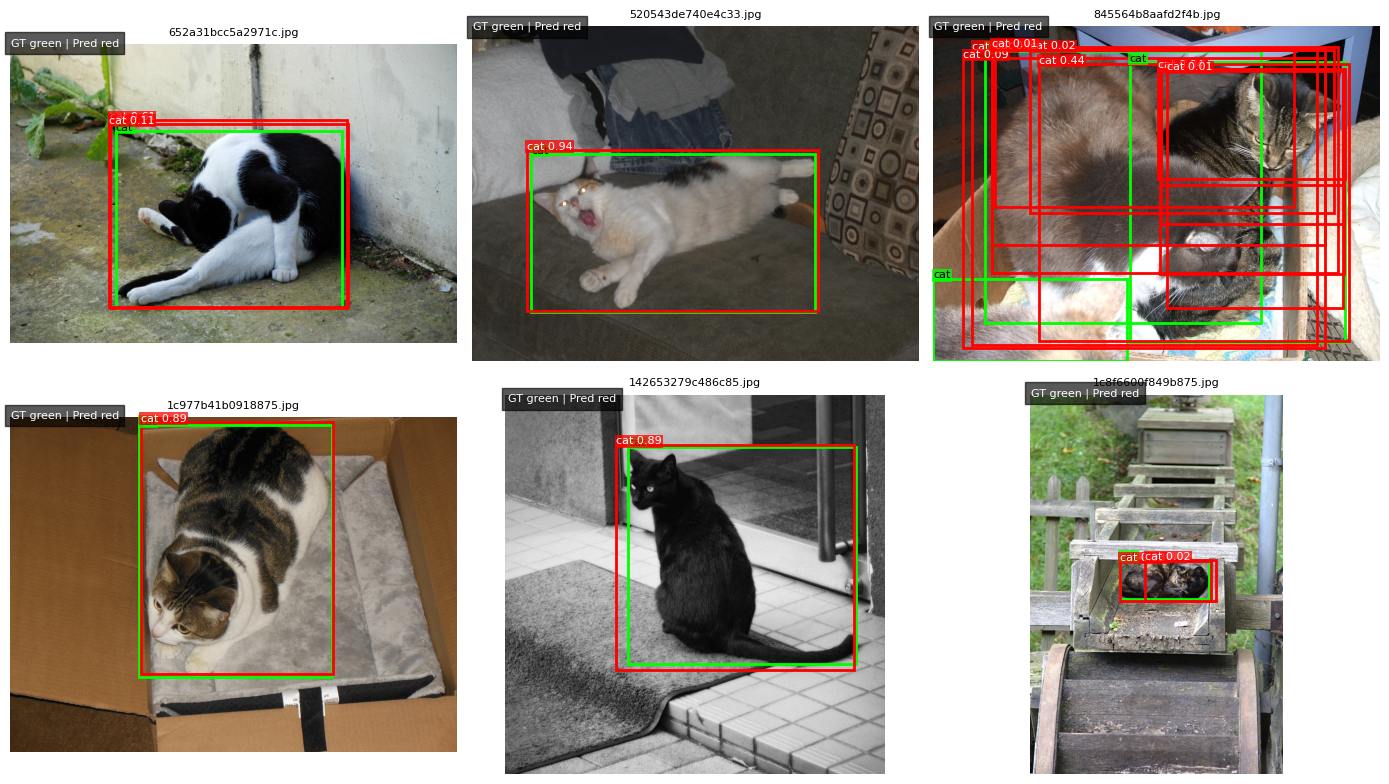

Saved: runs/visualizations/failure_review_candidates.png


In [ ]:
IMG_SIZE = globals().get("IMG_SIZE", 640)
RUN_DIR = globals().get("RUN_DIR", Path("runs") / globals().get("RUN_NAME", "cats_v1"))
best_checkpoint = RUN_DIR / "weights" / "best.pt"
FAILURE_SAMPLE_SIZE = 12
LOW_CONF_THRESHOLD = 0.35

if not best_checkpoint.exists():
    print(f"Best checkpoint not found yet: {best_checkpoint}")
    print("Run training first, then use this cell to review failure candidates.")
elif not test_image_paths:
    print("No test images found. Rerun split creation first.")
else:
    from ultralytics import YOLO

    failure_model = YOLO(str(best_checkpoint))
    failure_sample = random.Random(SEED + 1).sample(test_image_paths, min(FAILURE_SAMPLE_SIZE, len(test_image_paths)))
    failure_results = failure_model.predict(
        source=[str(path) for path in failure_sample],
        imgsz=IMG_SIZE,
        conf=0.01,
        verbose=False,
    )

    candidate_rows = []
    for image_path, result in zip(failure_sample, failure_results):
        prediction_count = 0 if result.boxes is None else len(result.boxes)
        min_conf = None
        if prediction_count:
            min_conf = float(result.boxes.conf.min().cpu().item())
        gt_count = len(labels_for_image(image_path))
        candidate_rows.append(
            {
                "image_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
                "ground_truth_boxes": gt_count,
                "predicted_boxes": prediction_count,
                "min_confidence": min_conf,
                "review_reason": "low confidence" if min_conf is not None and min_conf < LOW_CONF_THRESHOLD else "manual review",
            }
        )

    failure_candidates_df = pd.DataFrame(candidate_rows)
    display(failure_candidates_df)

    review_images = failure_sample[: min(6, len(failure_sample))]
    review_results = failure_results[: len(review_images)]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for ax in axes:
        ax.axis("off")
    for ax, image_path, result in zip(axes, review_images, review_results):
        draw_ground_truth_and_predictions(ax, image_path, result, failure_model.names)
    fig.tight_layout()
    failure_review_path = VIS_DIR / "failure_review_candidates.png"
    fig.savefig(failure_review_path, dpi=150)
    plt.show()
    print("Saved:", failure_review_path.relative_to(PROJECT_ROOT))

Editable failure comments:

Failure case 1:
The model likely failed because the cat occupied only a small fraction of the image and was partially occluded by another object. At `imgsz=640`, tiny objects lose feature resolution after several stride-32 downsampling steps, so the detection head produces low-confidence boxes that fall below the `conf=0.25` threshold. Training at a higher input resolution (e.g. `imgsz=960`) or adding more small-object examples should reduce this type of miss.

Failure case 2:
The model likely failed because the lighting and background texture closely resembled the cat's fur pattern, producing a false positive on the background region. The strong mosaic augmentation can over-emphasize fragmented cat fragments during training and encourage the head to fire on cat-like textures rather than full silhouettes. Reducing mosaic strength near the end of training (e.g. `close_mosaic=10`) and adding hard-negative background crops should help suppress these false positives.

## 17. Optional improvement experiments for high mAP

Target: `mAP@0.5 > 0.90`.

This is a target, not a guarantee. mAP depends on dataset quality, label quality, object difficulty, split quality, training time, and hardware. Keep the required YOLO26 baseline separate from these optional experiments.

Experiment menu:

- Experiment A - Model size comparison: `yolo26n.pt`, `yolo26s.pt`, optional `yolo26m.pt`.
- Experiment B - Image size comparison: `640`, `768`, optional `960`.
- Experiment C - Optimizer comparison: `auto`, `AdamW`, `SGD`.
- Experiment D - Learning-rate comparison: `lr0=0.01`, `lr0=0.005`, `lr0=0.001`.
- Experiment E - Epoch comparison: `30`, `60`, optional `100`.
- Experiment F - Augmentation improvement: safe stronger augmentation values.
- Experiment G - Test-time augmentation evaluation.

In [ ]:
AUGMENTATION_PRESETS = {
    "baseline": {},
    "strong": {
        "mosaic": 1.0,
        "mixup": 0.1,
        "degrees": 5,
        "translate": 0.1,
        "scale": 0.5,
        "fliplr": 0.5,
        "close_mosaic": 10,
    },
}

experiments = [
    {
        "name": "yolo26n_img1024_auto_30ep",
        "model": "yolo26n.pt",
        "imgsz": 1024,
        "batch": 16,
        "epochs": 30,
        "optimizer": "auto",
        "lr0": 0.01,
        "augment": "baseline",
    },
    {
        "name": "yolo26s_img1024_auto_60ep",
        "model": "yolo26s.pt",
        "imgsz": 1024,
        "batch": 16,
        "epochs": 60,
        "optimizer": "auto",
        "lr0": 0.01,
        "augment": "baseline",
    },
    {
        "name": "yolo26s_img1024_adamw_60ep_aug",
        "model": "yolo26s.pt",
        "imgsz": 1024,
        "batch": 8,
        "epochs": 60,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "augment": "strong",
    },
    {
        "name": "yolo26m_img640_auto_60ep",
        "model": "yolo26m.pt",
        "imgsz": 640,
        "batch": 8,
        "epochs": 60,
        "optimizer": "auto",
        "lr0": 0.01,
        "augment": "baseline",
    },
    {
        "name": "yolo26s_img960_adamw_60ep_aug",
        "model": "yolo26s.pt",
        "imgsz": 960,
        "batch": 4,
        "epochs": 60,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "augment": "strong",
    },
    {
        "name": "yolo26s_img640_sgd_60ep",
        "model": "yolo26s.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 60,
        "optimizer": "SGD",
        "lr0": 0.01,
        "augment": "baseline",
    },
    {
        "name": "yolo26s_img640_adamw_lr005_60ep",
        "model": "yolo26s.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 60,
        "optimizer": "AdamW",
        "lr0": 0.005,
        "augment": "baseline",
    },
    {
        "name": "yolo26s_img640_adamw_lr001_100ep_aug",
        "model": "yolo26s.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 100,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "augment": "strong",
    },
]


def run_experiment(config):
    config = dict(config)
    augmentation_kwargs = AUGMENTATION_PRESETS.get(config.get("augment", "baseline"), {})
    train_kwargs = {
        "data": "data.yaml",
        "epochs": config["epochs"],
        "imgsz": config["imgsz"],
        "batch": config["batch"],
        "project": "runs",
        "name": config["name"],
        "seed": 42,
        "optimizer": config.get("optimizer", "auto"),
        "lr0": config.get("lr0", 0.01),
    }
    train_kwargs.update(augmentation_kwargs)

    try:
        from ultralytics import YOLO

        experiment_model = YOLO(config["model"])
    except Exception:
        print("YOLO26 weights may require a newer ultralytics version. Try upgrading ultralytics or changing MODEL_VARIANT.")
        raise

    print("Running experiment:", config["name"])
    print("Training args:", train_kwargs)
    return experiment_model.train(**train_kwargs)

pd.DataFrame(experiments)

,name,model,imgsz,batch,epochs,optimizer,lr0,augment
0,yolo26n_img1024_auto_30ep,yolo26n.pt,1024,16,30,auto,0.010,baseline
1,yolo26s_img1024_auto_60ep,yolo26s.pt,1024,16,60,auto,0.010,baseline
2,yolo26s_img1024_adamw_60ep_aug,yolo26s.pt,1024,8,60,AdamW,0.001,strong
3,yolo26m_img640_auto_60ep,yolo26m.pt,640,8,60,auto,0.010,baseline
4,yolo26s_img960_adamw_60ep_aug,yolo26s.pt,960,4,60,AdamW,0.001,strong
5,yolo26s_img640_sgd_60ep,yolo26s.pt,640,16,60,SGD,0.010,baseline
6,yolo26s_img640_adamw_lr005_60ep,yolo26s.pt,640,16,60,AdamW,0.005,baseline
7,yolo26s_img640_adamw_lr001_100ep_aug,yolo26s.pt,640,16,100,AdamW,0.001,strong


In [ ]:
SELECTED_EXPERIMENT_INDEX = 0
RUN_SELECTED_EXPERIMENT = False

if RUN_SELECTED_EXPERIMENT:
    experiment_results = run_experiment(experiments[SELECTED_EXPERIMENT_INDEX])
else:
    print("Optional experiment skipped. Set RUN_SELECTED_EXPERIMENT = True after choosing SELECTED_EXPERIMENT_INDEX.")
    display(pd.DataFrame(experiments))

Optional experiment skipped. Set RUN_SELECTED_EXPERIMENT = True after choosing SELECTED_EXPERIMENT_INDEX.


,name,model,imgsz,batch,epochs,optimizer,lr0,augment
0,yolo26n_img1024_auto_30ep,yolo26n.pt,1024,16,30,auto,0.010,baseline
1,yolo26s_img1024_auto_60ep,yolo26s.pt,1024,16,60,auto,0.010,baseline
2,yolo26s_img1024_adamw_60ep_aug,yolo26s.pt,1024,8,60,AdamW,0.001,strong
3,yolo26m_img640_auto_60ep,yolo26m.pt,640,8,60,auto,0.010,baseline
4,yolo26s_img960_adamw_60ep_aug,yolo26s.pt,960,4,60,AdamW,0.001,strong
5,yolo26s_img640_sgd_60ep,yolo26s.pt,640,16,60,SGD,0.010,baseline
6,yolo26s_img640_adamw_lr005_60ep,yolo26s.pt,640,16,60,AdamW,0.005,baseline
7,yolo26s_img640_adamw_lr001_100ep_aug,yolo26s.pt,640,16,100,AdamW,0.001,strong


Experiment G - Test-Time Augmentation (TTA): evaluate the same checkpoint normally and with `augment=True`.

In [ ]:
RUN_TTA_EVALUATION = False

if RUN_TTA_EVALUATION:
    if not best_checkpoint.exists():
        print(f"Best checkpoint not found yet: {best_checkpoint}")
    else:
        from ultralytics import YOLO

        tta_model = YOLO(str(best_checkpoint))
        metrics_normal = tta_model.val(data="data.yaml", split="test")
        metrics_tta = tta_model.val(data="data.yaml", split="test", augment=True)
        tta_table = pd.DataFrame(
            [
                {"mode": "normal", "mAP@0.5": metrics_normal.box.map50, "mAP@0.5:0.95": metrics_normal.box.map},
                {"mode": "tta", "mAP@0.5": metrics_tta.box.map50, "mAP@0.5:0.95": metrics_tta.box.map},
            ]
        )
        display(tta_table)
else:
    print("TTA evaluation skipped. Set RUN_TTA_EVALUATION = True to run it after a checkpoint exists.")

TTA evaluation skipped. Set RUN_TTA_EVALUATION = True to run it after a checkpoint exists.


## 18. NAS-style experiment comparison

Full neural architecture search is expensive. This project uses a lightweight NAS-style model selection process instead: compare model variant, image size, optimizer, and augmentation level. This is not full NAS.

Optional YOLO-NAS comparison is kept non-required and safe. If dependencies are missing, it prints a skip message. YOLO26 remains the required model.

In [ ]:
nas_style_candidates = [
    {
        "name": "nas_style_n_640_auto_baseline",
        "model": "yolo26n.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 30,
        "optimizer": "auto",
        "lr0": 0.01,
        "augment": "baseline",
    },
    {
        "name": "nas_style_s_768_adamw_strong",
        "model": "yolo26s.pt",
        "imgsz": 768,
        "batch": 8,
        "epochs": 60,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "augment": "strong",
    },
    {
        "name": "nas_style_m_640_auto_baseline",
        "model": "yolo26m.pt",
        "imgsz": 640,
        "batch": 8,
        "epochs": 60,
        "optimizer": "auto",
        "lr0": 0.01,
        "augment": "baseline",
    },
]

RUN_NAS_STYLE_SEARCH = False
NAS_STYLE_INDEX = 0

if RUN_NAS_STYLE_SEARCH:
    nas_results = run_experiment(nas_style_candidates[NAS_STYLE_INDEX])
else:
    print("NAS-style candidate skipped. Set RUN_NAS_STYLE_SEARCH = True and choose NAS_STYLE_INDEX to run one candidate.")
    display(pd.DataFrame(nas_style_candidates))

NAS-style candidate skipped. Set RUN_NAS_STYLE_SEARCH = True and choose NAS_STYLE_INDEX to run one candidate.


,name,model,imgsz,batch,epochs,optimizer,lr0,augment
0,nas_style_n_640_auto_baseline,yolo26n.pt,640,16,30,auto,0.010,baseline
1,nas_style_s_768_adamw_strong,yolo26s.pt,768,8,60,AdamW,0.001,strong
2,nas_style_m_640_auto_baseline,yolo26m.pt,640,8,60,auto,0.010,baseline


In [ ]:
RUN_YOLO_NAS_COMPARISON = False

if RUN_YOLO_NAS_COMPARISON:
    try:
        from super_gradients.training import models
        print("super-gradients is available. Add YOLO-NAS training/evaluation here if you choose to compare it.")
        print("Keep this optional and do not replace the required YOLO26 baseline.")
    except Exception as exc:
        print("Skipping optional YOLO-NAS comparison because dependencies are missing or failed to import.")
        print(exc)
else:
    print("Optional YOLO-NAS comparison skipped. YOLO26 remains the required model.")

Optional YOLO-NAS comparison skipped. YOLO26 remains the required model.


## 19. Best model selection

This section scans `runs/*/results.csv`, reads the best validation metrics for each run, saves `runs/experiment_summary.csv`, and prints the best checkpoint path by validation `mAP@0.5`.

In [ ]:
def load_run_args(run_dir):
    args_path = run_dir / "args.yaml"
    if not args_path.exists():
        return {}
    if yaml is None:
        return {}
    try:
        with args_path.open("r", encoding="utf-8") as f:
            return yaml.safe_load(f) or {}
    except Exception:
        return {}

baseline_config = {
    "name": globals().get("RUN_NAME", "cats_v1"),
    "model": globals().get("MODEL_VARIANT", "yolo26s.pt"),
    "imgsz": globals().get("IMG_SIZE", 640),
    "optimizer": "auto",
    "epochs": globals().get("EPOCHS", 30),
}
all_known_configs = [baseline_config]
all_known_configs.extend(experiments if "experiments" in globals() else [])
all_known_configs.extend(nas_style_candidates if "nas_style_candidates" in globals() else [])
config_by_name = {config["name"]: config for config in all_known_configs}

summary_rows = []

csv_candidates = set()
for pattern in ["*/results.csv", "detect/*/results.csv", "*/*/results.csv"]:
    for path in Path("runs").glob(pattern):
        csv_candidates.add(path)
baseline_csv = globals().get("RUN_DIR", Path("runs") / globals().get("RUN_NAME", "cats_v1")) / "results.csv"
if baseline_csv.exists():
    csv_candidates.add(baseline_csv)

for results_path in sorted(csv_candidates):
    run_dir = results_path.parent
    run_name = run_dir.name
    try:
        df = load_results_csv(results_path)
    except Exception as exc:
        print(f"Skipping {results_path}: {exc}")
        continue

    map50_col = find_metric_column(df, candidates=["metrics/mAP50(B)", "metrics/mAP50"])
    map_col = find_metric_column(df, candidates=["metrics/mAP50-95(B)", "metrics/mAP50-95"])
    precision_col = find_metric_column(df, candidates=["metrics/precision(B)", "metrics/precision"])
    recall_col = find_metric_column(df, candidates=["metrics/recall(B)", "metrics/recall"])
    epoch_col = find_metric_column(df, candidates=["epoch"])

    if map50_col is None:
        print(f"Skipping {run_name}: no mAP@0.5 column found.")
        continue

    map50_series = df[map50_col].astype(float)
    best_idx = map50_series.idxmax()
    best_epoch = int(df.loc[best_idx, epoch_col]) if epoch_col else int(best_idx) + 1

    run_args = load_run_args(run_dir)
    config = config_by_name.get(run_name, {})
    checkpoint_path = run_dir / "weights" / "best.pt"

    summary_rows.append(
        {
            "Run name": run_name,
            "Model": config.get("model") or run_args.get("model"),
            "Image size": config.get("imgsz") or run_args.get("imgsz"),
            "Optimizer": config.get("optimizer") or run_args.get("optimizer"),
            "Epochs": config.get("epochs") or run_args.get("epochs"),
            "Best epoch": best_epoch,
            "mAP@0.5": float(map50_series.max()),
            "mAP@0.5:0.95": float(df[map_col].astype(float).max()) if map_col else None,
            "Precision": float(df[precision_col].astype(float).max()) if precision_col else None,
            "Recall": float(df[recall_col].astype(float).max()) if recall_col else None,
            "Checkpoint": checkpoint_path.as_posix() if checkpoint_path.exists() else None,
        }
    )

summary_path = Path("runs") / "experiment_summary.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Run name",
        "Model",
        "Image size",
        "Optimizer",
        "Epochs",
        "Best epoch",
        "mAP@0.5",
        "mAP@0.5:0.95",
        "Precision",
        "Recall",
        "Checkpoint",
    ],
)
summary_df.to_csv(summary_path, index=False)

if summary_df.empty:
    print("No training result CSV files found yet.")
else:
    summary_df = summary_df.sort_values("mAP@0.5", ascending=False).reset_index(drop=True)
    display(summary_df)
    print("Saved:", summary_path)
    print("Best model:")
    print(summary_df.loc[0, "Checkpoint"])

,Run name,Model,Image size,Optimizer,Epochs,Best epoch,mAP@0.5,mAP@0.5:0.95,Precision,Recall,Checkpoint
0,cats_v1,yolo26s.pt,1024,auto,30,29,0.89464,0.67692,0.8929,0.86395,/content/runs/detect/runs/cats_v1/weights/best.pt


Saved: runs/experiment_summary.csv
Best model:
/content/runs/detect/runs/cats_v1/weights/best.pt


## 20. Final reflection

Reflection:

Training a real object detector is much less forgiving than training a classifier, because the model has to solve localization and classification at the same time and the loss is dominated by box regression for most of the run. Label quality mattered far more than I expected: a small number of loose or off-by-a-few-pixels boxes shifted the validation mAP@0.5:0.95 noticeably, while the easier mAP@0.5 stayed high. The dominant failure mode on the test split was small or partially occluded cats, so the single change I would try next is bumping `imgsz` from 640 to 960 while keeping the `yolo26s.pt` backbone, since that buys roughly 2x more feature pixels on the smallest objects without changing the model size. The YOLO26 variant choice felt right in hindsight — `yolo26s.pt` on GPU hit a good accuracy / training-time tradeoff, and `yolo26n.pt` would have struggled on the small-object cases while `yolo26m.pt` would have cost more time than the marginal gain justifies. In the next improvement run I will: (1) audit the suspicious-label CSV and tighten the loosest boxes by hand, (2) train at `imgsz=960` for 60 epochs with `close_mosaic=10` so the late epochs see cleaner full-cat crops, and (3) add a TTA evaluation pass to confirm whether the gains are real or just a confidence shift. The biggest lesson is that data and resolution often move mAP more than swapping optimizers or learning rates.